### 시퀀스-투-시퀀스(Sequence-to-Sequence, seq2seq)
- 번역기에서 대표적으로 사용되는 모델
- 인코더와 디코더라는 두 개의 모듈로 구성
  - 인코더(Encoder) : 입력된 문장의 모든 단어를 학습하여 정보를 압축하여 **의미를 해석하는 모델**
  - 디코터(Decoder) : 데이터를 받아서 번역된 단어를 순차적으로 **출력하는 모델**

### 인코더 - 디코더
- 인코더 : 입력된 문장의 모든 단어를 학습하여 정보를 압축해서 의미를 해석하는데 집중된 모델 (의미를 해석하는데 집중된 모델)
- 디코더 : 데이터를 받아서 번역된 단어를 순차적으로 출력하는데 집중된 모델 (출력에 집중된 모델)

### Transformer의 등장 배경
- RNN계열은 긴 시퀀스를 처리할 때 순차적으로 처리를 하기 때문에 느림 + 장기 의존성 문제(기억손실문제)를 해결하기 어렵다.
  - 장기 의존성 : 과거의 정보가 마지막까지 전달이 되지 못하는 현상(기억손실)
- 구글에서 논문을 발표하여 처음 나온 모델로서 (논문 : Attention is all you need) 기존의 Seq2Seq의 구조인 인코더-디코더 형식을 따르면서, 어탠션에 집중된 모델
- Attention : 문장 내에 단어들 사이의 관계성을 파악하여 특정 단어를 처리할 때 다른 단어들보다 더 집중하여 계산해야 한다는 것을 파악하는 기술 (중요한 단어를 색출)
  - Query : 처리해야 되는 주체
  - Key : 비교 대상이 되는 단어들의 정보
  - Value : 각 단어가 가진 실제 의미 값

### Transformer
  - 필요한 것은 주의 집중(Attention is All You Need) 논문으로 2017년 발표
  - 순환과 컨볼루션을 완전히 배제하고 오로지 Attention 메커니즘에만 기반을 둔 새롭고 단순한 신경망 아키텍처

  - 인코더와 디코더로 구성
  - 인코더
    - 트랜스포머는 하이퍼파라미터인 num_layers 개수의 인코더 층을 쌓음
    - 하나의 인코더 층은 크게 셀프 어텐션과 피드 포워드 신경망의 2개의 서브층(sublayer)으로 구성
      - Multi-head Self-Attention : 셀프 어텐션을 병렬적으로 사용
      - Position-wise FFNN : 일반적인 피드 포워드 신경망
    - 인코딩의 출력은 디코더로 전달

  - 디코더
    - num_layers 개수의 디코더 층을 쌓음  
    - 인코더에서 보낸 출력을 디코더 층의 연산에 사용
    - 디코더는 3개 층으로 구성
      - Masked Multi-head Self-Attention (Self Attention과 Look-ahead mask): 현재 시점의 예측에서 현재 시점보다 미래에 있는 단어들을 참고하지 못하도록 룩-어헤드 마스크(look-ahead mask)를 사용
        - 트랜스포머는 문장 행렬로 입력을 한 번에 받으므로 현재 시점의 단어를 예측하고자 할 때, 입력 문장 행렬로부터 미래 시점의 단어까지도 참고할 수 있는 현상이 발생
      - Multi-head Self-Attention (Encoder-Decoder Attention) : 멀티 헤드 어텐션을 수행
      - Position-wise FFNN

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/transformer_attention_overview.png" width=60%>   
</center>    




## Transformer 구조

> **Positional Encoding (위치 인코딩)**
> - Self-Attention 기반 모델은 입력 순서를 순차적으로 처리하지 못 함
> - 이에 대해 **<U>토큰 간 순서 정보**</U>를 알려주기 위함 (한 문장을 병렬로 처리하면서도 각 단어의 위치를 인지하게 됨)

> **Encoder Self-Attention**
> - 인코더는 **<U>입력 문장의 모든 단어 간의 관계**</U>를 계산하여, 문장 전체에서 중요한 정보를 파악

> **Add & Norm**
> - 출력에 원래 입력을 **<U>더하고, 값을 정규화**</U>하여 안정된 학습을 도움
> - ResNet - Skip Connection 개념 차용

> **Feed Forward**
> - 활성화 함수(ReLU)를 사용해 입력을 처리해서, 비선형성을 통해 모델이 더 복잡한 패턴을 학습할 수 있게 만드는 **<U>완전 연결 신경망**</U> (쉽게 MLP 떠올리면 됨)

> **Masked Decoder Self-Attention**
> - 디코더가 예측할 때 미래 단어를 **<U>참조하지 못하게 막아**</U>, 이전 단어들만을 사용해 순차적으로 예측

> **Encoder-Decoder Self-Attention**
> - Seq2Seq Attention (Bahdanau/Luong)에서 발전된 형태
> - **<U>디코더가 인코더의 출력을 참조**</U>하여,  입력 문장과의 관계를 기반으로 더 정확한 출력을 생성

#### Transformer 종류

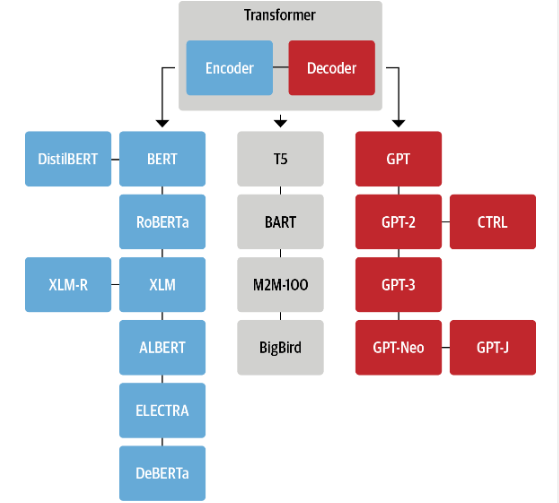

### Transformers의 종류
- 넓은 관점에서 트랜스포머 모델은 세 가지로 범주화 할 수 있음

> BERT 계열
> - Transformer 모델의 Encoder만 활용
> - 입력 전체를 한 번에 보고, 양방향으로 학습
> - 대표 모델 : BERT, ELECTRA 등
> - 주 사용처 : 문장 분류, 개체명 인식, 문장 유사도 등 전체 문장에 대한 이해를 요구하는 작업
>     - 빠른 추론과 가벼운 배포가 장점, 분류/검색/추천/임베딩 등 읽기 중심의 task에 많이 쓰임

> Seq2Seq 계열
> - Sequence-to-Sequence(Encoding → Decoding) 구조
> - 다양한 생성, 이해 작업에 강점을 가짐
> - 대표 모델 : T5, BART 등
> - 주 사용처 : 제로샷 분류, 요약/번역/재작성 등
>     - 다수 task(요약, 번역, 생성 등)을 하나의 모델로 운영 할 때 자주 사용

> GPT 계열
> - Transformer 모델의 Decoder만 활용
> - 입력을 순차적으로 처리하며 다음 토큰 예측(순방향)
> - 대표 모델 : GPT, GPT-2, CTRL, GPT-3, GPT-4 등
> - 주 사용처 : 텍스트 생성, 대화형 에이전트 등
>     - 창의적 생성이 장점, 프롬프트 엔지니어링이 중요할 때 선호

### 허깅페이스
- 인공지능 관련 데이터셋, 모델, 테스팅 공간 등을 공유하는 커뮤니티 웹서비스
- 여러가지 task(목적)를 통해 내가 원하는 목적에 맞는 모델을 가져다가 사용할 수 있다.
- 내 데이터에 맞게끔 목적을 변경하는 파인튜닝 작업을 할 수 있다.
- 내가 만든 모델을 업로드하여 여러 사람이 같이 사용해볼 수 있다.
- https://huggingface.co/

## Hugging Face_Transformers 라이브러리 설치하기

- **<U>Colab**</U> : 구글에서 제공하는 클라우드 컴퓨팅 서비스, 주피터 노트북을 기반으로 작동하며, GPU 자원을 무료로 일부 활용할 수 있음

- **<U>Hugging face**</U> : 인공지능 관련 데이터셋, 모델, 테스팅 공간 등을 공유하는 커뮤니티 웹서비스
---

In [ ]:
# transformer 라이브러리 설치
!pip install transformers[torch]==4.42

In [ ]:
# 파이프라인 사용 도구 불러오기
from transformers import pipeline

# transformers : Hugging Face에서 제공되는 Transformer기반의 모델을 쉽고 일관성있게 사용할 수 있도록 도와주는 도구
# pipeline : 다양한 task에 대해 간단히 사용해볼 수 있도록 도와주는 도구

## NLP(Natural Language Processing) Task 맛보기
- HuggingFace : https://huggingface.co/models
- Tasks : 작업 단위
- Hugging Face Transformers Documents : https://huggingface.co/learn/llm-course/ko/chapter1/3?fw=pt


### 문장번역 모델 사용 (Translation)

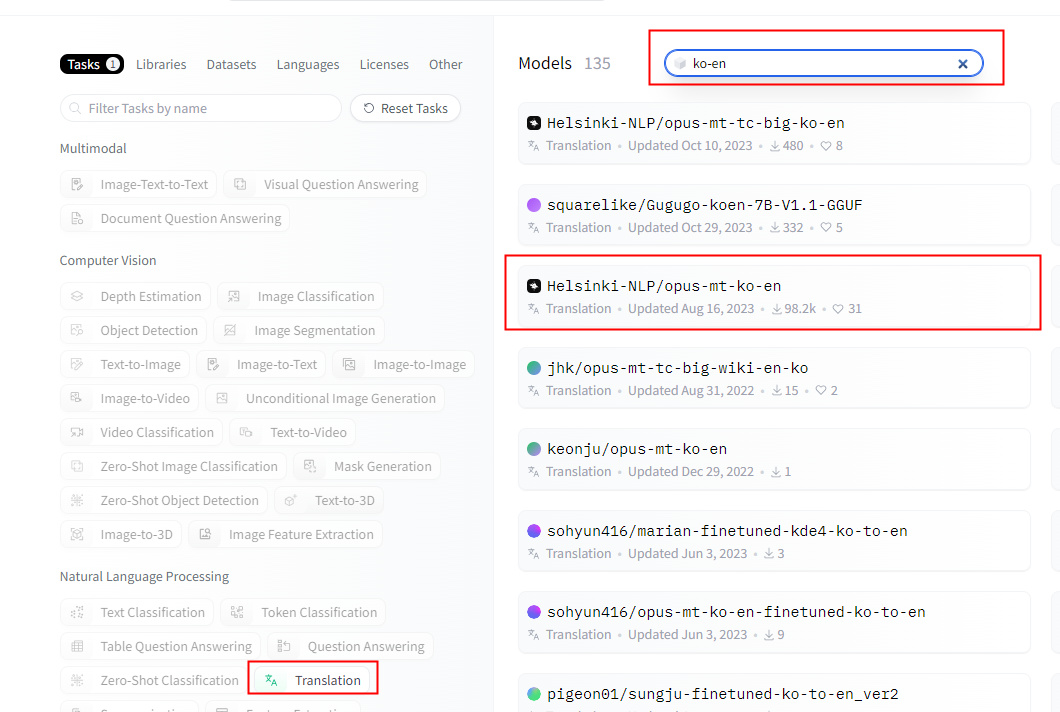

- 파이프라인 활용하면 토크나이징(토큰화) ->  모델 예측 -> 결과 해석의 과정을 한 번에 해결 가능
- 장점
  1. 한 줄로 모든 과정이 해결 가능
  2. 자동으로 전후 처리를 해줌

- 단점
1. 커스텀마이징(EX. 파인 튜닝(Fine Tunning 등 ) 불가
2. 배치, 학습 불가

- 파이프라인을 활용하면 `토크나이징→모델 예측→결과 해석`의 과정을 한 번에 처리 가능
- 허나, 단점도 존재함

| 방식           | 장점                          | 단점                            |
| ------------ | --------------------------- | ----------------------------- |
| **파이프라인**    | - 한 줄로 추론<br>- 자동 전후처리      | - 커스터마이징(ex.Fine Tuning 등) 불가<br>- 배치·학습 불가     |
| **직접 모델 호출** | - 세부 제어 가능<br>- 배치 처리·학습 가능 | - 코드 작성량 증가<br>- 전처리 직접 구현 필요 |


In [ ]:
# 번역모델
# task : translation
translator = pipeline(
    task='translation',
    model='Helsinki-NLP/opus-mt-ko-en',
    device=0
)


# task : 모델 사용 목적
# model : 사용할 모델의 경로 (모델 이름)
# device : GPU사용 여부 (-1 : CPU / 0 : GPU / 'cuda' : 자동으로 사용)

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


#### 파이프라인 Task 종류

| 파이프라인                      | 설명                                |
| -------------------------- | --------------------------------- |
| `feature-extraction`       | 특징 추출 (텍스트에 대한 벡터 표현 추출)          |
| `fill-mask`                | 마스크 채우기                           |
| `ner`                      | 개체명 인식 (Named Entity Recognition) |
| `question-answering`       | 질의 응답                             |
| `sentiment-analysis`       | 감정 분석                             |
| `summarization`            | 요약                                |
| `text-generation`          | 텍스트 생성                            |
| `translation`              | 번역                                |
| `zero-shot-classification` | 제로샷 분류 (레이블 분류)                   |


In [ ]:
# 번역 진행
translator("나는 오늘 집에 가서 쉬고 싶어요")

[{'translation_text': 'I want to go home today and rest.'}]

### 긍정, 부정에 대한 감정분석 모델 사용 (KoElectra) - BERT계열 모델

- **<U>Text Classification**</U> : 텍스트를 입력으로 받아 텍스트가 어떤 종류의 범주에 속하는지를 구분하는 작업
- 감성분석(sentiment-analysis) : 텍스트 내에서 사람의 기분, 감정, 의견(Topic) 등을 예측하는 기술

- task : sentiment-analysis
- 한국어에 특화된 ELECTRA 모델
- 초기 BERT에 비해 학습 효율 측면에서 유리하게 만들어진 모델

In [ ]:
classifier = pipeline(
    task='sentiment-analysis',
    model='daekeun-ml/koelectra-small-v3-nsmc',
    device=0
)

config.json:   0%|          | 0.00/914 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/56.5M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# koelectra모델을 사용하여 긍정/부정 분류
classifier("잘~ 한다~")

[{'label': '1', 'score': 0.8760995864868164}]

- 파이프라인 활용하면 토크나이징(토큰화) ->  모델 예측 -> 결과 해석의 과정을 한 번에 해결 가능
- 장점
  1. 한 줄로 모든 과정이 해결 가능
  2. 자동으로 전후 처리를 해줌

- 단점
1. 커스텀마이징(EX. 파인 튜닝(Fine Tunning 등 ) 불가
2. 배치, 학습 불가

- 파이프라인을 활용하면 `토크나이징→모델 예측→결과 해석`의 과정을 한 번에 처리 가능
- 허나, 단점도 존재함

| 방식           | 장점                          | 단점                            |
| ------------ | --------------------------- | ----------------------------- |
| **파이프라인**    | - 한 줄로 추론<br>- 자동 전후처리      | - 커스터마이징(ex.Fine Tuning 등) 불가<br>- 배치·학습 불가     |
| **직접 모델 호출** | - 세부 제어 가능<br>- 배치 처리·학습 가능 | - 코드 작성량 증가<br>- 전처리 직접 구현 필요 |
